Here we are trying to determine the Mpeak bin to use for MultiCAM application on the hydro-only experiment, where we don't perform any matching just use the dark matter part of the hydro simulation and predict the hydro/galaxy parameters.

In [4]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass


In [40]:
# stellar mass of 100 particles
np.log10(1.4e6 * 100)

np.float64(8.146128035678238)

In [8]:
# read tree data 
with open("../../data/out-trees-tng100-bar.npz", 'rb') as fp:
    hydro_data = np.load(fp)
    _mpeak = hydro_data['mpeak']
    _stellar_mass =hydro_data['stellar_mass']

_mpeak.shape, _stellar_mass.shape

((101431,), (101431,))

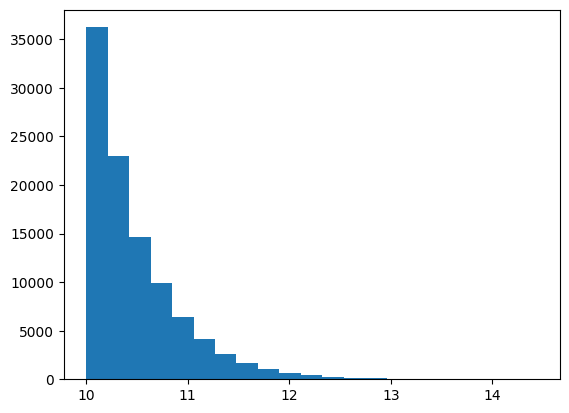

In [ ]:
mask = _mpeak > 0
plt.hist(np.log10(_mpeak[mask]),bins=21); # already in M_sun units

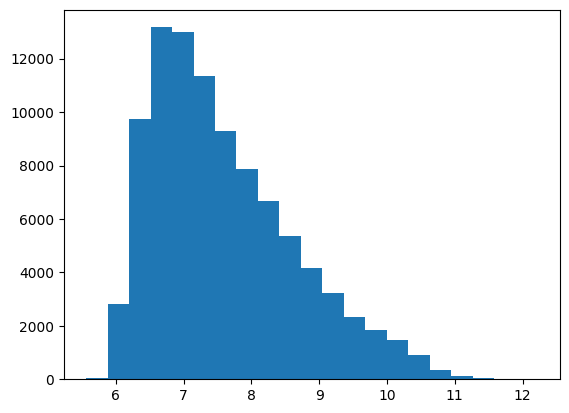

In [17]:
mask = _stellar_mass > 0
plt.hist(np.log10(_stellar_mass[mask]),bins=21);

In [ ]:
star_mask = (_stellar_mass > 0) & (_mpeak > 0)

log_smass = np.log10(_stellar_mass[star_mask])
log_mpeak = np.log10(_mpeak[star_mask])

log_smass.shape, log_mpeak.shape

((93851,), (93851,))

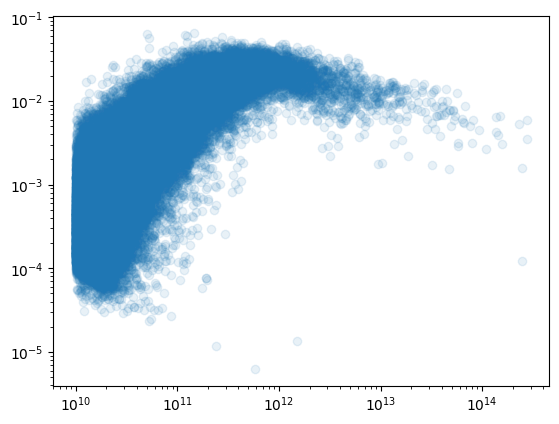

In [ ]:
# does this look more like the stellar to halo mass relation??

plt.plot(10**log_mpeak, (10**log_smass / 10**log_mpeak), 'o', alpha=0.1)
plt.yscale('log')
plt.xscale('log')


# more reasonable???

In [59]:
smbin = (8.2, 8.7)
# smbin = (8.7, 9.5)
# smbin = (8.2, 10.0)
mask1 = (log_smass > smbin[0]) & (log_smass < smbin[1])
sum(mask1)

np.int64(9301)

(10.394, 11.158)
Extent: 0.764


Text(0.5, 0, 'M_peak')

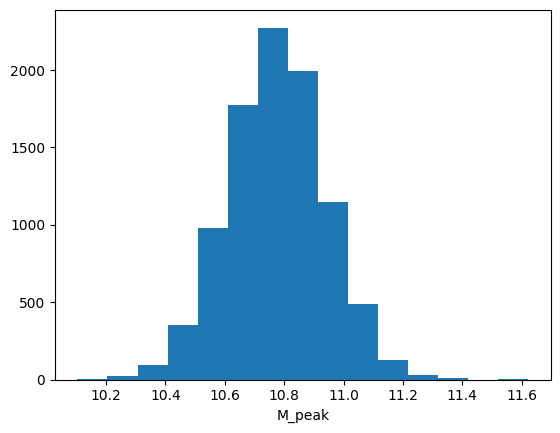

In [62]:
x = log_mpeak[mask1]
plt.hist(x, bins=15);

q1 = np.quantile(x, 0.01)
q2 = np.quantile(x, 0.99)
print(f"({q1:.3f}, {q2:.3f})")
print(f"Extent: {q2 - q1:.3f}")
plt.xlabel("M_peak")